In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score
import os

path = os.getenv("DATA_PATH")
df = pd.read_csv(path)
target = "Problem_SKU"
seed = 1337 
# One-hot encode Storage_Size (drop size_4 as baseline)
size_dummies = pd.get_dummies(df['Storage_Size'], prefix='Size', drop_first=True).astype(int)

# Encode Defect_In_Linked_Receive as 0/1
defect_linked_num = df['Defect_In_Linked_Receive'].astype(int)

# Numeric features (keep standardized)
numeric_features = [
    "Global_SKU_Defect_Rate_%_std",
    "ABS_Volume_Difference_std",
    "Aisle_Hold_%_std",
    "#_Pick_Events_std",
    "#_Pick_Events_In_Clique_std",
    "#_Picks_std",
    "#_Picks_In_Clique_std",
    "Time_In_Loc_std",
    "Current_Max_Volume_std",
]

feature_cols = numeric_features + list(size_dummies.columns) + ['Defect_In_Linked_Receive']

# Combine all properly encoded features
X = df[numeric_features].copy()
X = pd.concat([X, size_dummies, defect_linked_num], axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

dt = DecisionTreeClassifier(
    max_depth=None,        # let it grow; you can cap later
    min_samples_leaf=50,   # mild regularization
    random_state=seed,
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree")
print(classification_report(y_test, y_pred_dt, digits=3))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dt))

import numpy as np

fi_dt = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(fi_dt)

Decision Tree
              precision    recall  f1-score   support

       False      0.945     0.987     0.965     50954
        True      0.621     0.270     0.377      4046

    accuracy                          0.934     55000
   macro avg      0.783     0.629     0.671     55000
weighted avg      0.921     0.934     0.922     55000

ROC AUC: 0.8144272748038606
#_Picks_In_Clique_std           0.308731
Aisle_Hold_%_std                0.146597
Current_Max_Volume_std          0.126887
#_Picks_std                     0.112853
ABS_Volume_Difference_std       0.101935
#_Pick_Events_In_Clique_std     0.091101
Global_SKU_Defect_Rate_%_std    0.064291
#_Pick_Events_std               0.017249
Time_In_Loc_std                 0.013118
Defect_In_Linked_Receive        0.008358
Size_size_3                     0.004815
Size_size_2                     0.003028
Size_size_4                     0.001036
dtype: float64


In [2]:
from sklearn.tree import DecisionTreeClassifier

dt_recall = DecisionTreeClassifier(
    class_weight='balanced',  # ← weights minority class higher
    min_samples_leaf=50,   # same regularization as before
    random_state=seed
)

dt_recall.fit(X_train, y_train)

y_pred_dt = dt_recall.predict(X_test)
y_proba_dt = dt_recall.predict_proba(X_test)[:, 1]

print("Decision Tree")
print(classification_report(y_test, y_pred_dt, digits=3))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dt))

import numpy as np

fi_dt_recall = pd.Series(dt_recall.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(fi_dt_recall)

Decision Tree
              precision    recall  f1-score   support

       False      0.972     0.768     0.858     50954
        True      0.197     0.717     0.309      4046

    accuracy                          0.765     55000
   macro avg      0.584     0.743     0.584     55000
weighted avg      0.915     0.765     0.818     55000

ROC AUC: 0.8080060376828695
#_Picks_In_Clique_std           0.361309
Aisle_Hold_%_std                0.146907
Current_Max_Volume_std          0.109160
#_Picks_std                     0.092217
ABS_Volume_Difference_std       0.079113
#_Pick_Events_In_Clique_std     0.068479
Global_SKU_Defect_Rate_%_std    0.058503
Time_In_Loc_std                 0.032350
#_Pick_Events_std               0.031026
Size_size_3                     0.008389
Size_size_2                     0.006208
Defect_In_Linked_Receive        0.004795
Size_size_4                     0.001546
dtype: float64


## Threshold Tuning for High Precision

The default 0.5 threshold is arbitrary. Since AUC=0.814, the probability scores contain real signal — raising the threshold trades recall for precision on a continuous curve. Find the operating point that hits your precision floor.

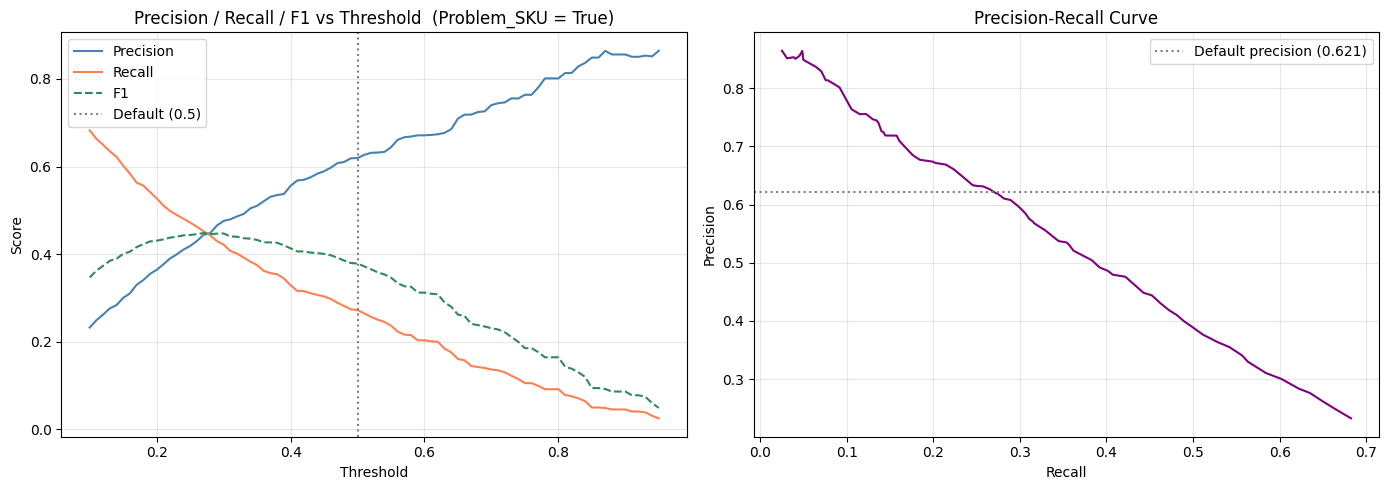


 Prec Target  Threshold   Recall       F1    Flagged   of 4046 True
--------------------------------------------------------------------
        0.70       0.65    0.161    0.262        916            650
        0.75       0.73    0.122    0.211        655            495
        0.80       0.78    0.092    0.165        463            371
        0.85       0.87    0.049    0.092        228            197
        0.90        N/A
        0.95        N/A


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Use the high-precision DT (no class_weight)
y_proba_hp = dt.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.96, 0.01)
precisions, recalls, f1s, n_flagged = [], [], [], []

for t in thresholds:
    y_pred_t = (y_proba_hp >= t).astype(int)
    flagged = y_pred_t.sum()
    if flagged == 0:
        precisions.append(np.nan)
        recalls.append(0.0)
        f1s.append(0.0)
    else:
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
        f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    n_flagged.append(flagged)

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)
n_flagged  = np.array(n_flagged)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresholds, precisions, label="Precision", color="steelblue")
ax.plot(thresholds, recalls,    label="Recall",    color="coral")
ax.plot(thresholds, f1s,        label="F1",        color="seagreen", linestyle="--")
ax.axvline(0.5, color="gray", linestyle=":", label="Default (0.5)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold  (Problem_SKU = True)")
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
valid = ~np.isnan(precisions)
ax2.plot(recalls[valid], precisions[valid], color="purple")
ax2.axhline(0.621, color="gray", linestyle=":", label="Default precision (0.621)")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Precision target table ---
print(f"\n{'Prec Target':>12} {'Threshold':>10} {'Recall':>8} {'F1':>8} {'Flagged':>10} {'of 4046 True':>14}")
print("-" * 68)
for target in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    mask = precisions >= target
    if mask.any():
        # highest recall at or above this precision
        best_idx = np.where(mask)[0][np.argmax(recalls[mask])]
        t  = thresholds[best_idx]
        r  = recalls[best_idx]
        f  = f1s[best_idx]
        nf = n_flagged[best_idx]
        caught = int(round(r * 4046))
        print(f"{target:>12.2f} {t:>10.2f} {r:>8.3f} {f:>8.3f} {nf:>10,} {caught:>14,}")
    else:
        print(f"{target:>12.2f} {'N/A':>10}")


## F1-Optimized Decision Tree

Grid search over class weights and tree structure, scoring directly on F1. Class weight is the main lever — it shifts the model's internal decision boundary without changing the threshold.

In [4]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'max_depth':        [5, 8, 12, None],
    'min_samples_leaf': [20, 50, 100],
    'class_weight': [
        None,
        {False: 1, True: 3},
        {False: 1, True: 5},
        {False: 1, True: 7},
        {False: 1, True: 10},
        'balanced',
    ],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=seed),
    param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
gs.fit(X_train, y_train)

print(f"\nBest params: {gs.best_params_}")
print(f"Best CV F1:  {gs.best_score_:.4f}")

dt_f1 = gs.best_estimator_
y_pred_f1  = dt_f1.predict(X_test)
y_proba_f1 = dt_f1.predict_proba(X_test)[:, 1]

print("\nF1-Optimized Decision Tree (threshold=0.5)")
print(classification_report(y_test, y_pred_f1, digits=3))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_f1):.4f}")

fi_f1 = pd.Series(dt_f1.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(fi_f1)


Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best params: {'class_weight': {False: 1, True: 3}, 'max_depth': 12, 'min_samples_leaf': 100}
Best CV F1:  0.4521

F1-Optimized Decision Tree (threshold=0.5)
              precision    recall  f1-score   support

       False      0.958     0.950     0.954     50954
        True      0.433     0.477     0.454      4046

    accuracy                          0.916     55000
   macro avg      0.695     0.714     0.704     55000
weighted avg      0.920     0.916     0.917     55000

ROC AUC: 0.8476

Feature importances:
#_Picks_In_Clique_std           0.443169
Aisle_Hold_%_std                0.140193
Current_Max_Volume_std          0.110584
#_Picks_std                     0.099325
ABS_Volume_Difference_std       0.073664
#_Pick_Events_In_Clique_std     0.066360
Global_SKU_Defect_Rate_%_std    0.042198
#_Pick_Events_std               0.006770
Defect_In_Linked_Receive        0.006232
Time_In_Loc_std                 0.005247
Size_

F1-maximizing threshold: 0.49  →  F1=0.4571
Precision: 0.430   Recall: 0.488

Classification report at threshold=0.49:
              precision    recall  f1-score   support

       False      0.959     0.949     0.954     50954
        True      0.430     0.488     0.457      4046

    accuracy                          0.915     55000
   macro avg      0.694     0.718     0.705     55000
weighted avg      0.920     0.915     0.917     55000



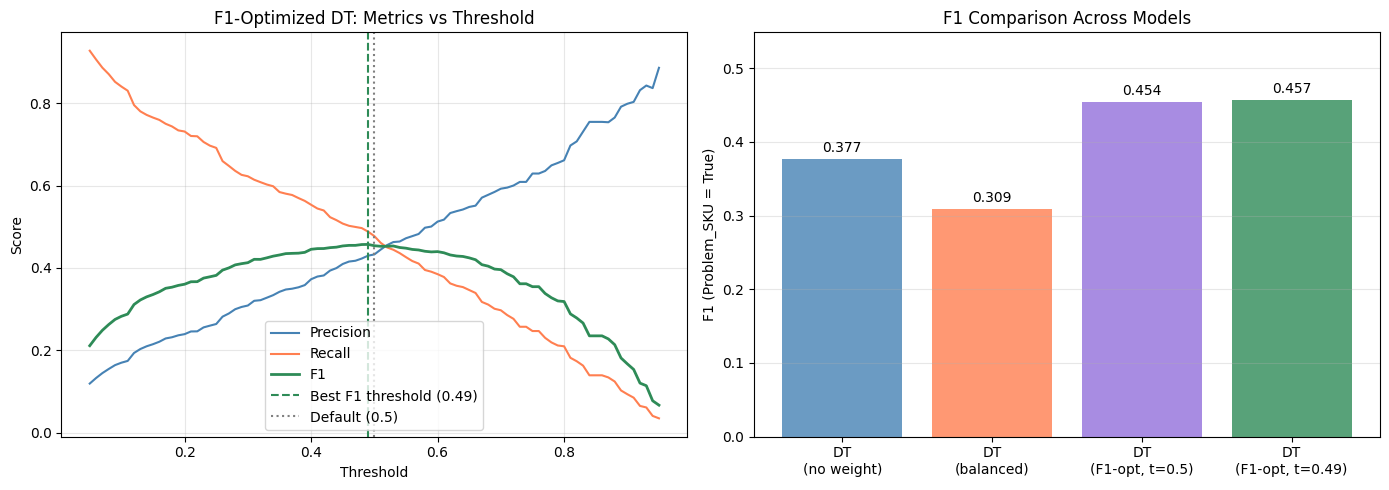

In [5]:
import matplotlib.pyplot as plt

# Sweep threshold on the F1-optimized model to find its best operating point
gs_thresholds = np.arange(0.05, 0.96, 0.01)
gs_precs, gs_recs, gs_f1s, gs_nf = [], [], [], []

for t in gs_thresholds:
    y_pred_t = (y_proba_f1 >= t).astype(int)
    flagged = y_pred_t.sum()
    if flagged == 0:
        gs_precs.append(np.nan)
        gs_recs.append(0.0)
        gs_f1s.append(0.0)
    else:
        gs_precs.append(precision_score(y_test, y_pred_t, zero_division=0))
        gs_recs.append(recall_score(y_test, y_pred_t, zero_division=0))
        gs_f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    gs_nf.append(flagged)

gs_precs = np.array(gs_precs)
gs_recs  = np.array(gs_recs)
gs_f1s   = np.array(gs_f1s)
gs_nf    = np.array(gs_nf)

best_t_idx = int(np.nanargmax(gs_f1s))
best_t     = gs_thresholds[best_t_idx]
best_f1    = gs_f1s[best_t_idx]

print(f"F1-maximizing threshold: {best_t:.2f}  →  F1={best_f1:.4f}")
print(f"Precision: {gs_precs[best_t_idx]:.3f}   Recall: {gs_recs[best_t_idx]:.3f}\n")

y_pred_tuned = (y_proba_f1 >= best_t).astype(int)
print(f"Classification report at threshold={best_t:.2f}:")
print(classification_report(y_test, y_pred_tuned, digits=3))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(gs_thresholds, gs_precs, label="Precision", color="steelblue")
ax.plot(gs_thresholds, gs_recs,  label="Recall",    color="coral")
ax.plot(gs_thresholds, gs_f1s,   label="F1",        color="seagreen", linewidth=2)
ax.axvline(best_t, color="seagreen", linestyle="--",
           label=f"Best F1 threshold ({best_t:.2f})")
ax.axvline(0.5, color="gray", linestyle=":", label="Default (0.5)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("F1-Optimized DT: Metrics vs Threshold")
ax.legend()
ax.grid(alpha=0.3)

# Summary bar chart comparing all models
ax2 = axes[1]
model_names = [
    "DT\n(no weight)",
    "DT\n(balanced)",
    "DT\n(F1-opt, t=0.5)",
    f"DT\n(F1-opt, t={best_t:.2f})",
]
t50_idx = int(np.argmin(np.abs(gs_thresholds - 0.5)))
f1_scores_compare = [
    0.377,
    0.309,
    gs_f1s[t50_idx],
    best_f1,
]
bars = ax2.bar(model_names, f1_scores_compare,
               color=["steelblue", "coral", "mediumpurple", "seagreen"],
               alpha=0.8)
for bar, val in zip(bars, f1_scores_compare):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontsize=10)
ax2.set_ylim(0, max(f1_scores_compare) * 1.2)
ax2.set_ylabel("F1 (Problem_SKU = True)")
ax2.set_title("F1 Comparison Across Models")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
